***Import and load structure***

In [67]:
from Bio.PDB import PDBParser
from pathlib import Path

pdb_path = Path("../data/raw/1LYZ.pdb")

parser = PDBParser(QUIET=True)
structure = parser.get_structure("1LYZ", pdb_path)

print("Structure loaded:", structure)

Structure loaded: <Structure id=1LYZ>


***count models***

In [68]:
models = list(structure.get_models())
print("Number of models:", len(models))

Number of models: 1


***count chains***

In [69]:
model = models[0]
chains = list(model.get_chains())

print("Chains:")
for chain in chains:
    print(chain.id)

Chains:
A


***count residues***

In [70]:
from Bio.PDB.Polypeptide import is_aa

residue_count = 0

for residue in model.get_residues():
    if is_aa(residue, standard=True):
        residue_count += 1

print("Number of amino acid residues:", residue_count)

Number of amino acid residues: 129


***count atoms***

In [71]:
atom_count = sum(1 for _ in model.get_atoms())
print("Number of atoms:", atom_count)

Number of atoms: 1102


## Structure Summary (1LYZ)

- Models: 1
- Chains: 1 (Chain A)
- Residues: 129 amino acids
- Atoms: 1102

### Interpretation
This confirms that lysozyme is a small, single-chain protein, making it suitable for structure-based protein engineering and computational design workflows.

***Extract sequence***

In [72]:
from Bio.PDB.Polypeptide import is_aa
from Bio.Data.IUPACData import protein_letters_3to1

model = structure[0]

sequence = []

for residue in model.get_residues():
    if is_aa(residue, standard=True):
        resname = residue.get_resname().capitalize()

        try:
            sequence.append(protein_letters_3to1[resname])
        except KeyError:
            sequence.append("X")  # unknown residue

sequence_str = "".join(sequence)

print("Sequence length:", len(sequence_str))
print("Sequence (first 50 aa):", sequence_str[:50])

Sequence length: 129
Sequence (first 50 aa): KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGS


***Add full sequence print- for visualization***

In [73]:
print(sequence_str)

KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGSTDYGILQINSRWWCNDGRTPGSRNLCNIPCSALLSSDITASVNCAKKIVSDGNGMNAWVAWRNRCKGTDVQAWIRGCRL


***save sequence to file***

In [74]:
from pathlib import Path

output_path = Path("../data/processed/1LYZ_sequence.txt")

with open(output_path, "w") as f:
    f.write(sequence_str)

print("Saved sequence to:", output_path)

Saved sequence to: ../data/processed/1LYZ_sequence.txt


***verify file***

In [75]:
cat ../data/processed/1LYZ_sequence.txt

KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGSTDYGILQINSRWWCNDGRTPGSRNLCNIPCSALLSSDITASVNCAKKIVSDGNGMNAWVAWRNRCKGTDVQAWIRGCRL

## Sequence–Structure Relationship

The sequence was extracted directly from the structure file rather than using a reference database.

### Why this matters
- ensures consistency with the actual structure used
- accounts for missing or unresolved residues
- avoids mismatch between sequence and structure

### Implication for protein engineering
All future mutations and designs will be based on this sequence, ensuring compatibility with structural constraints.

***creating a structured, reusable data table from Biopython objects***

In [76]:
import pandas as pd
from Bio.PDB.Polypeptide import is_aa
from Bio.Data.IUPACData import protein_letters_3to1

model = structure[0]

residue_rows = []

for chain in model.get_chains():
    for residue in chain.get_residues():
        if not is_aa(residue, standard=True):
            continue

        hetflag, resseq, icode = residue.id
        resname_3 = residue.get_resname().capitalize()

        try:
            resname_1 = protein_letters_3to1[resname_3]
        except KeyError:
            resname_1 = "X"

        atom_names = {atom.get_name() for atom in residue}

        has_N = "N" in atom_names
        has_CA = "CA" in atom_names
        has_C = "C" in atom_names
        has_O = "O" in atom_names

        if has_CA:
            ca_coord = residue["CA"].get_coord()
            ca_x, ca_y, ca_z = map(float, ca_coord)
        else:
            ca_x, ca_y, ca_z = None, None, None

        residue_rows.append({
            "chain_id": chain.id,
            "residue_number": resseq,
            "insertion_code": icode.strip() if isinstance(icode, str) else "",
            "residue_name_3": resname_3,
            "residue_name_1": resname_1,
            "has_N": has_N,
            "has_CA": has_CA,
            "has_C": has_C,
            "has_O": has_O,
            "ca_x": ca_x,
            "ca_y": ca_y,
            "ca_z": ca_z,
        })

residue_df = pd.DataFrame(residue_rows)
residue_df.head()

,chain_id,residue_number,insertion_code,residue_name_3,residue_name_1,has_N,has_CA,has_C,has_O,ca_x,ca_y,ca_z
0,A,1,,Lys,K,True,True,True,True,2.439,10.217,9.791
1,A,2,,Val,V,True,True,True,True,2.307,14.172,7.580
2,A,3,,Phe,F,True,True,True,True,-1.187,15.293,7.580
3,A,4,,Gly,G,True,True,True,True,-2.637,17.468,4.864
4,A,5,,Arg,R,True,True,True,True,-3.823,20.764,5.685


***check the total number of residues***

In [77]:
print("Total residues in residue table:", len(residue_df))

Total residues in residue table: 129


***quick summary cell***

In [78]:
print("Total residues in residue table:", len(residue_df))
print()

print("Backbone atom presence:")
print("has_N :", residue_df["has_N"].sum())
print("has_CA:", residue_df["has_CA"].sum())
print("has_C :", residue_df["has_C"].sum())
print("has_O :", residue_df["has_O"].sum())
print()

print("Missing CA coordinates:", residue_df["ca_x"].isna().sum())

Total residues in residue table: 129

Backbone atom presence:
has_N : 129
has_CA: 129
has_C : 129
has_O : 129

Missing CA coordinates: 0


***Save the residue table***

In [79]:
from pathlib import Path

output_path = Path("../data/processed/residue_table.csv")
residue_df.to_csv(output_path, index=False)

print("Saved updated residue table to:", output_path)

Saved updated residue table to: ../data/processed/residue_table.csv


***verify the saved table***

In [80]:
saved_df = pd.read_csv("../data/processed/residue_table.csv")
saved_df.head()

,chain_id,residue_number,insertion_code,residue_name_3,residue_name_1,has_N,has_CA,has_C,has_O,ca_x,ca_y,ca_z
0,A,1,NaN,Lys,K,True,True,True,True,2.439,10.217,9.791
1,A,2,NaN,Val,V,True,True,True,True,2.307,14.172,7.580
2,A,3,NaN,Phe,F,True,True,True,True,-1.187,15.293,7.580
3,A,4,NaN,Gly,G,True,True,True,True,-2.637,17.468,4.864
4,A,5,NaN,Arg,R,True,True,True,True,-3.823,20.764,5.685


## Residue Coordinates and Backbone Completeness

The residue table now includes residue-level structural coordinates using Cα positions and flags indicating whether key backbone atoms are present.

### Why this matters
- Cα coordinates provide a simple residue-level spatial representation
- backbone completeness helps assess structural reliability
- this enables future distance calculations, mutation mapping, and structural filtering

### Current limitation
Cα coordinates are a simplified residue representation. Full side-chain geometry and local environment features will be added later.

***estimating the geometric center of the folded protein***

In [81]:
import numpy as np

# Use only residues with CA coordinates
coord_mask = residue_df["ca_x"].notna() & residue_df["ca_y"].notna() & residue_df["ca_z"].notna()

coords = residue_df.loc[coord_mask, ["ca_x", "ca_y", "ca_z"]].to_numpy()

# Protein centroid
centroid = coords.mean(axis=0)

print("Protein centroid:", centroid)

Protein centroid: [-0.53044187 20.35241089 19.20634101]


***computing distance from centroid***

In [82]:
# Compute distance of each residue CA from centroid
residue_df["dist_from_centroid"] = np.sqrt(
    (residue_df["ca_x"] - centroid[0]) ** 2 +
    (residue_df["ca_y"] - centroid[1]) ** 2 +
    (residue_df["ca_z"] - centroid[2]) ** 2
)

residue_df[["chain_id", "residue_number", "residue_name_1", "dist_from_centroid"]].head()

,chain_id,residue_number,residue_name_1,dist_from_centroid
0,A,1,K,14.148950
1,A,2,V,13.469238
2,A,3,F,12.696476
3,A,4,G,14.780398
4,A,5,R,13.922536


***assign rough environment labels***

In [83]:
distance_cutoff = residue_df["dist_from_centroid"].median()

residue_df["environment"] = np.where(
    residue_df["dist_from_centroid"] < distance_cutoff,
    "core",
    "surface"
)

print("Distance cutoff:", distance_cutoff)
print()
print(residue_df["environment"].value_counts())

Distance cutoff: 13.011870737474087

environment
surface    65
core       64
Name: count, dtype: int64


***inspect example residues***

In [84]:
print("Core-like residues:")
display(
    residue_df.loc[residue_df["environment"] == "core",
                   ["chain_id", "residue_number", "residue_name_1", "dist_from_centroid"]].head(10)
)

print("Surface-like residues:")
display(
    residue_df.loc[residue_df["environment"] == "surface",
                   ["chain_id", "residue_number", "residue_name_1", "dist_from_centroid"]].head(10)
)

Core-like residues:


,chain_id,residue_number,residue_name_1,dist_from_centroid
2,A,3,F,12.696476
7,A,8,L,11.389901
8,A,9,A,12.358220
10,A,11,A,12.797993
11,A,12,M,10.326589
14,A,15,H,12.655490
16,A,17,L,10.370492
22,A,23,Y,12.636188
24,A,25,L,12.401094
25,A,26,G,12.551703


Surface-like residues:


,chain_id,residue_number,residue_name_1,dist_from_centroid
0,A,1,K,14.148950
1,A,2,V,13.469238
3,A,4,G,14.780398
4,A,5,R,13.922536
5,A,6,C,16.210970
6,A,7,E,15.110238
9,A,10,A,14.784206
12,A,13,K,13.492573
13,A,14,R,15.203697
15,A,16,G,13.336577


***visualization***

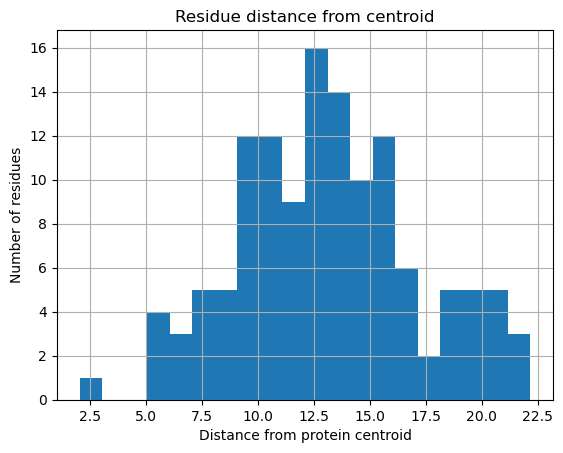

In [85]:
import matplotlib.pyplot as plt

residue_df["dist_from_centroid"].hist(bins=20)
plt.xlabel("Distance from protein centroid")
plt.ylabel("Number of residues")
plt.title("Residue distance from centroid")
plt.show()

***save the updated residue table***

In [86]:
from pathlib import Path

output_path = Path("../data/processed/residue_table.csv")
residue_df.to_csv(output_path, index=False)

print("Saved updated residue table to:", output_path)

Saved updated residue table to: ../data/processed/residue_table.csv


## Rough Structural Environment Labels

A first approximate structural environment label was added using Cα distance from the protein centroid.

### Labels
- `core`: residues closer to the protein center
- `surface`: residues farther from the protein center

### Why this matters
This provides a simple first approximation of mutational context and helps distinguish residues that may be more structurally constrained from those that may be more mutation-tolerant.

### Important limitation
This is a geometric heuristic, not a true solvent accessibility calculation. Later versions will use DSSP or SASA-based methods for more realistic surface/burial estimates.

***add sequence -order index***

In [87]:
residue_df = residue_df.sort_values(
    by=["chain_id", "residue_number", "insertion_code"]
).reset_index(drop=True)

residue_df["seq_index"] = range(len(residue_df))

residue_df.head()

,chain_id,residue_number,insertion_code,residue_name_3,residue_name_1,has_N,has_CA,has_C,has_O,ca_x,ca_y,ca_z,dist_from_centroid,environment,seq_index
0,A,1,,Lys,K,True,True,True,True,2.439,10.217,9.791,14.148950,surface,0
1,A,2,,Val,V,True,True,True,True,2.307,14.172,7.580,13.469238,surface,1
2,A,3,,Phe,F,True,True,True,True,-1.187,15.293,7.580,12.696476,core,2
3,A,4,,Gly,G,True,True,True,True,-2.637,17.468,4.864,14.780398,surface,3
4,A,5,,Arg,R,True,True,True,True,-3.823,20.764,5.685,13.922536,surface,4


***Add the simple geometric heuristic***

In [88]:
import numpy as np

# Start with default label
residue_df["ss_simple"] = "loop"

# Work chain by chain
for chain_id, chain_df in residue_df.groupby("chain_id"):
    chain_idx = chain_df.index.tolist()

    for i in range(1, len(chain_idx) - 1):
        prev_idx = chain_idx[i - 1]
        curr_idx = chain_idx[i]
        next_idx = chain_idx[i + 1]

        prev_ca = residue_df.loc[prev_idx, ["ca_x", "ca_y", "ca_z"]].to_numpy(dtype=float)
        curr_ca = residue_df.loc[curr_idx, ["ca_x", "ca_y", "ca_z"]].to_numpy(dtype=float)
        next_ca = residue_df.loc[next_idx, ["ca_x", "ca_y", "ca_z"]].to_numpy(dtype=float)

        if np.any(np.isnan(prev_ca)) or np.any(np.isnan(curr_ca)) or np.any(np.isnan(next_ca)):
            continue

        v1 = curr_ca - prev_ca
        v2 = next_ca - curr_ca

        norm1 = np.linalg.norm(v1)
        norm2 = np.linalg.norm(v2)

        if norm1 == 0 or norm2 == 0:
            continue

        cos_angle = np.dot(v1, v2) / (norm1 * norm2)

        # Rough geometric rules:
        # straighter local geometry -> sheet-like
        # bent but regular -> helix-like
        # everything else -> loop
        if cos_angle > 0.35:
            residue_df.loc[curr_idx, "ss_simple"] = "sheet"
        elif -0.2 <= cos_angle <= 0.35:
            residue_df.loc[curr_idx, "ss_simple"] = "helix"
        else:
            residue_df.loc[curr_idx, "ss_simple"] = "loop"

***inspect results***

In [89]:
print(residue_df["ss_simple"].value_counts())

ss_simple
helix    97
sheet    30
loop      2
Name: count, dtype: int64


***Visualize the labels***

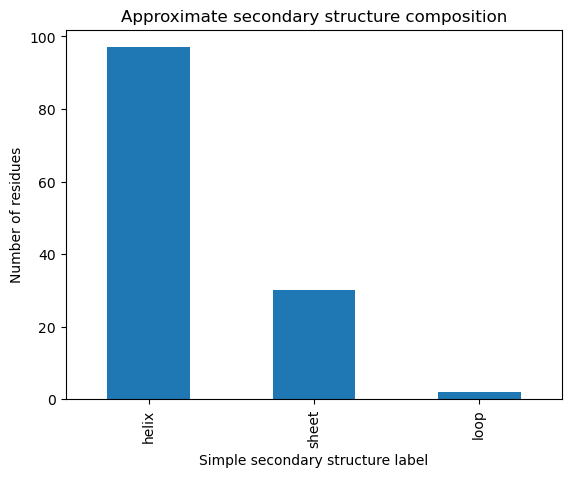

In [90]:
residue_df["ss_simple"].value_counts().plot(kind="bar")
plt.xlabel("Simple secondary structure label")
plt.ylabel("Number of residues")
plt.title("Approximate secondary structure composition")
plt.show()

***inspect a few rows***

In [91]:
residue_df[[
    "chain_id", "residue_number", "residue_name_1",
    "environment", "ss_simple"
]].head(20)

,chain_id,residue_number,residue_name_1,environment,ss_simple
0,A,1,K,surface,loop
1,A,2,V,surface,helix
2,A,3,F,core,sheet
3,A,4,G,surface,sheet
4,A,5,R,surface,helix
5,A,6,C,surface,helix
6,A,7,E,surface,helix
7,A,8,L,core,helix
8,A,9,A,core,helix
9,A,10,A,surface,helix


***save the updated table***

In [92]:
from pathlib import Path

output_path = Path("../data/processed/residue_table.csv")
residue_df.to_csv(output_path, index=False)

print("Saved updated residue table to:", output_path)

Saved updated residue table to: ../data/processed/residue_table.csv


## Approximate Secondary Structure Labels

A simple geometric heuristic was used to assign rough secondary-structure labels based on local Cα geometry.

### Labels
- `helix`
- `sheet`
- `loop`

### Why this matters
Secondary structure affects mutational tolerance, packing, and local backbone constraints.

### Important limitation
These labels are approximate and are not equivalent to DSSP or experimentally assigned secondary structure. A more rigorous annotation method will be added later.